In [3]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import re


1. Realizará una solicitud HTTP GET a la [siguiente](https://www.ocasionplus.com/coches-ocasion?type%3DCAR%26sort%3DFECHAOP_DESC%26page%3D2) url.

In [5]:
# definimos la url de la página de la vamos a sacar datos
url_coches = "https://www.ocasionplus.com/coches-ocasion?type=CAR&sort=FECHAOP_DESC&page=2"

# hacemos la request a la página de la que queremos sacar la info
res_coches = requests.get(url_coches)



2. Comprobará el código de estado de la respuesta. Si el código no es 200 (OK), imprimirá un mensaje de error y retornará `None`.

In [7]:
# vemos si todo ha ido bien
print("La respuesta de la petición es:", res_coches.status_code)

La respuesta de la petición es: 200


3. Extraerá los nombres de los coches, los precios rebajados, los precios originales y la información de los kilómetros recorridos de la página.

<!DOCTYPE html>
<html lang="es">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <link as="image" fetchpriority="high" href="/hera/icons/prevArrow.svg" rel="preload"/>
  <link as="image" fetchpriority="high" href="/hera/icons/nextArrow.svg" rel="preload"/>
  <link as="image" fetchpriority="high" href="https://images.grupoocasionplus.com/_qX35Nkn2MNsG3zJyuzvvJLO6alAPAqnDqHA24tz1qs/mobilex2/aHR0cHM6Ly9vY2FzaW9ucGx1cy5lc3RhdGljb3NtZi5jb20vZm90b3NfYW51bmNpb3MvMDAvMDUvOTAvNTcvOTkvNC94MDEuanBnP21kNT0wYjkyM2ZlMmI3MjQwODhiOTNhZGY2NGU3MGE0ZjlkYg" rel="preload"/>
  <link data-precedence="next" href="/hera/_next/static/css/b1f3862f1eca62dd.css" rel="stylesheet"/>
  <link data-precedence="next" href="/hera/_next/static/css/51c286ae0cbd7c1d.css" rel="stylesheet"/>
  <link data-precedence="next" href="/hera/_next/static/css/2037a48a6aaa070d.css" rel="stylesheet"/>
  <link data-precedence="next" href="/hera/_next/static/css/0fec6697d79e9eb4.
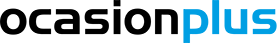

In [8]:
# creamos el objeto BeautifulSoup para poder acceder al contenido solicitado
sopa_coches = BeautifulSoup(res_coches.content, 'html.parser')

# mostramos por pantalla los resultados del objeto de Beautiful Soup. El método ".prettify()" nos ayuda a visualizar los resultados de una forma más amigable
print(sopa_coches.prettify())

In [12]:
lista_nombre_producto = sopa_coches.find_all("div", class_="cardVehicle_description__Gp9vd")
lista_nombre_producto[0]

<div class="cardVehicle_description__Gp9vd"><div class="cardVehicle_prices__yMKDU"><h2 class="cardVehicle_column_text__EvQkB"><span class="cardVehicle_spot__e6YZx" data-test="span-brand-model">Peugeot 2008</span><span class="cardVehicle_finance__SG6JV" data-test="span-version">SUV BlueHDi 120 S&amp;S GT Line (120 CV)</span></h2><div class="cardVehicle_column_amount___VgVU"><div class="cardVehicle_amount__JGeQe"><span class="cardVehicle_spot__e6YZx" data-test="span-price">13.100€</span><span class="cardVehicle_finance__SG6JV" data-test="span-finance">11.909€</span></div><div class="cardVehicle_quota__onan1"><span>desde</span><span class="cardVehicle_cuote__eSQXl" data-test="span-finace-quote">229<!-- -->€</span><span>/mes</span></div></div></div><div class="characteristics_characteristics__ZF6yE cardVehicle_characteristics__vq4Lm"><div class="characteristics_content__vqUuu characteristics_card__Arz6I"><div class="flex-column characteristics_iconEnvironmentalLabel__8vrFb"><img alt="disti

In [15]:
lista_nombre_producto = sopa_coches.find_all("h2", {"class":"cardVehicle_column_text__EvQkB"})
# mostramos los resultados del método ".find_all()". Como dijimos al inicio este método nos va a devolver una lista
# Si lo exploramos un poco veremos que tenemos una lista de elemento y que tiene muchas cosas, pero si nos fijamos bien tenemos todos los nombres de los teléfonos que tenemos en la página web

#print("El resultado del método '.find_all()' es: \n",   lista_nombre_producto)
# es el momento de sacar la información útil del método que hemos usado previamente. Para eso lo primero que vamos a hacer es crearnos una lista donde iremos almacenado los resultados que queremos

coche = []
# dado que es una lista lo que vamos a hacer es iterar por la lista para poder acceder a cada uno de los elementos

for i in lista_nombre_producto:
    # utilizamos el método ".getText()" para sacar el texto de cada uno de los elementos y lo apendeamos a la lista que hemos creado previamente.
    coche.append(i.getText())

#print("\n--------------------------\n")
print("Los resultados de extraer el texto de cada uno de los elementos es:\n", coche)


Los resultados de extraer el texto de cada uno de los elementos es:
 ['Peugeot 2008SUV BlueHDi 120 S&S GT Line (120 CV)', 'Ford Tourneo Connect1.0 EcoBoost Titanium (100 CV)', 'Seat León1.5 eTSI S&S FR Go XL DSG Auto (150 CV)', 'Mercedes Clase AMercedes-Benz 180 Pack AMG (136 CV)', 'Seat León1.5 EcoTSI S&S Style (130 CV)', 'BMW X3xDrive20d (190 CV)', 'Peugeot 2061.4 HDI X-Line (70 CV)', 'KIA Niro1.6 GDi HEV Híbrido Drive (141 CV)', 'Renault ArkanaZen E-Tech Híbrido (145 CV)', 'BMW Serie 3318d (150 CV) Pack M', 'Seat Ateca2.0 TDI S&S Xcellence 4Drive (150 CV)', 'Seat LeónST 1.5 TSI S&S Xcellence Go L (150 CV)', 'Peugeot 2008SUV SUV BlueHDi 100 S&S Style (100 CV)', 'Nissan QASHQAIDIG-T 115 Unique Edition (115 CV)', 'Mini CountrymanMINI Countryman Countryman Cooper S (184 CV)', 'Toyota C-HR180H Advance (184 CV)', 'Seat Arona1.0 TSI FR Go2 (110 CV)', 'Citroën C3BlueHDi 100 Collection (99 CV)', 'Ford Focus1.0 Ecoboost S&S Edition (125 CV)', 'Opel Combo Life1.5 TD Business Edition L (102 CV)

In [17]:
lista_nombre_producto = sopa_coches.find_all("span", {"cardVehicle_column_text__EvQkB"})
# mostramos los resultados del método ".find_all()". Como dijimos al inicio este método nos va a devolver una lista
# Si lo exploramos un poco veremos que tenemos una lista de elemento y que tiene muchas cosas, pero si nos fijamos bien tenemos todos los nombres de los teléfonos que tenemos en la página web

#print("El resultado del método '.find_all()' es: \n",   lista_nombre_producto)
# es el momento de sacar la información útil del método que hemos usado previamente. Para eso lo primero que vamos a hacer es crearnos una lista donde iremos almacenado los resultados que queremos

coche = []
# dado que es una lista lo que vamos a hacer es iterar por la lista para poder acceder a cada uno de los elementos

for i in lista_nombre_producto:
    # utilizamos el método ".getText()" para sacar el texto de cada uno de los elementos y lo apendeamos a la lista que hemos creado previamente.
    coche.append(i.getText())

#print("\n--------------------------\n")
print("Los resultados de extraer el texto de cada uno de los elementos es:\n", coche)

Los resultados de extraer el texto de cada uno de los elementos es:
 []



4. Organizará los datos extraídos en un DataFrame de pandas con las siguientes columnas:

   - "coche": Nombres de los coches.

   - "precio_rebajado": Precios rebajados.

   - "precio_original": Precios originales.

   - "km": Kilómetros recorridos.

5. Retornará el DataFrame resultante.

6. Una vez extraida toda la información deberéis almacenar toda la información en un DataFrame.